In [1]:
%pip install matplotlib requests moviepy


Note: you may need to restart the kernel to use updated packages.


# V17a — frozen V14a exact-D4 readout bridge

The experiment sequence has shown that streaming stochastic histories improve
generalization, while pose locking and exact signed endpoint polarity do not
repair the coarse V14c result. Before another end-to-end run, this notebook asks
whether the state of the sharp V14a positive control can be read sharply by a
symmetry-preserving decoder.

The V14a NCA and age-128 states are frozen. Two decoder-only arms receive the
same 24 training states, eight selection states, exact-D4 augmentation, and
2,500 updates. `interpolated_only` removes local coordinates from the V14a
SIREN. `d4_orbit` retains the ordered four-cell neighborhood and subcell query
phase, then averages its descriptor over all eight D4 views. Sixteen final
states are opened only after checkpoint selection.

This does not make V14a's anisotropic dynamics acceptable. It is a readout
capacity bridge: only a decoder that is both sharp and exact-D4 should enter the
next expensive joint IsoNCA run.

Upload `v14a_cells2pixels_lizard_reference_artifacts.tar.gz` to `/workspace/`,
run all cells on CUDA, and download
`/workspace/v17a_frozen_v14a_d4_readout_bridge_artifacts.tar.gz`.


In [2]:
VERSION = 'V17a'
SLUG = 'v17a_frozen_v14a_d4_readout_bridge'


In [3]:
#@title Remote GPU setup, exact V14a source, and lizard target
from io import BytesIO
from pathlib import Path
import hashlib
import importlib.util
import json
import os
import random
import subprocess
import sys
import tarfile

WORKSPACE_ROOT = Path('/workspace') if Path('/workspace').is_dir() else Path.cwd()
REFERENCE_NAME = 'v14a_cells2pixels_lizard_reference_artifacts.tar.gz'
reference_candidates = [
    WORKSPACE_ROOT / REFERENCE_NAME,
    Path.cwd() / REFERENCE_NAME,
    Path.cwd() / 'notebooks-executed/v14a' / REFERENCE_NAME,
]
REFERENCE_PATH = next((path.resolve() for path in reference_candidates if path.is_file()), None)
if REFERENCE_PATH is None:
    raise FileNotFoundError('Upload ' + REFERENCE_NAME + ' into ' + str(WORKSPACE_ROOT))

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

with tarfile.open(REFERENCE_PATH) as archive:
    members = {Path(member.name).name: member for member in archive.getmembers()
               if member.isfile()}
    required = {'metrics.json', 'model.pth', 'decoder.pth'}
    if not required <= members.keys():
        raise RuntimeError('V14a artifact is missing: ' + str(sorted(required - members.keys())))
    reference_metrics = json.loads(archive.extractfile(members['metrics.json']).read())
    if reference_metrics.get('status') != 'complete':
        raise RuntimeError('The supplied V14a artifact is not complete')
    SOURCE_ROOT = WORKSPACE_ROOT / (SLUG + '_source')
    SOURCE_ROOT.mkdir(parents=True, exist_ok=True)
    for name in ('model.pth', 'decoder.pth'):
        target_path = SOURCE_ROOT / name
        target_path.write_bytes(archive.extractfile(members[name]).read())

repo_candidates = [Path.cwd(), WORKSPACE_ROOT / 'Cells2Pixels']
repo_path = next((path.resolve() for path in repo_candidates
                  if (path / 'models/nca2d.py').is_file()), None)
if repo_path is None:
    repo_path = (WORKSPACE_ROOT / 'Cells2Pixels').resolve()
    subprocess.run([
        'git', 'clone', '--branch', 'isotropic', '--single-branch',
        'https://github.com/IvanLudvig/Cells2Pixels.git', str(repo_path)], check=True)
os.chdir(repo_path)
if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))

if importlib.util.find_spec('lpips') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'lpips'], check=True)

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import torch.nn.functional as F
from PIL import Image
from lpips import LPIPS
from torch.utils.checkpoint import checkpoint

from losses.image_loss import ImageLoss
from losses.invariant_image_loss import InvariantImageLoss
from models.isotropic_lppn import _sine_mlp
from models.nca2d import GrowingNCA
from models.siren import Siren
from utils.render import Renderer2D

if not torch.cuda.is_available():
    raise RuntimeError('A CUDA GPU runtime is required')
device = torch.device('cuda')
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

TARGET_IMAGE_PATH = Path('data/morphology_png/lizard.png')
if not TARGET_IMAGE_PATH.is_file():
    response = requests.get(
        'https://github.com/googlefonts/noto-emoji/blob/main/png/512/emoji_u1f98e.png?raw=true',
        headers={'User-Agent': 'Cells2Pixels V17a'}, timeout=60)
    response.raise_for_status()
    TARGET_IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)
    Image.open(BytesIO(response.content)).convert('RGBA').save(TARGET_IMAGE_PATH)

if file_hash(TARGET_IMAGE_PATH) != reference_metrics['config']['target_hash']:
    raise RuntimeError('V14a artifact and local lizard target hashes differ')

expected_sources = reference_metrics['config'].get('repository_sources', {})
actual_sources = {name: file_hash(repo_path / name) for name in (
    'models/nca2d.py', 'models/siren.py', 'losses/image_loss.py',
    'losses/invariant_image_loss.py', 'utils/render.py')}
source_mismatches = {name: (expected_sources.get(name), value)
                     for name, value in actual_sources.items()
                     if expected_sources.get(name) != value}
if source_mismatches:
    raise RuntimeError('Repository sources differ from V14a: ' + str(source_mismatches))

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

source_model = GrowingNCA(
    channels=32, fc_dim=256, padding='circular', perception_kernels=4,
    update_prob=0.5, device=device, precision=torch.float16).to(device).eval()
source_decoder = Siren(
    in_features=32, coord_dim=2, hidden_features=64, hidden_layers=2,
    out_features=4, outermost_linear=True, first_omega_0=10.0,
    hidden_omega_0=10.0, fx='linear', activation='sin', num_frequencies=1,
    disable=False, disable_coords=False).to(device).eval()
source_model.load_state_dict(torch.load(
    SOURCE_ROOT / 'model.pth', map_location=device, weights_only=True))
source_decoder.load_state_dict(torch.load(
    SOURCE_ROOT / 'decoder.pth', map_location=device, weights_only=True))
source_model.requires_grad_(False)
source_decoder.requires_grad_(False)

renderer = Renderer2D(
    scale_factor=4, padding='circular', mode='bilinear',
    fs_shader='vanilla', precision=torch.float16)
OUTPUT_ROOT = WORKSPACE_ROOT / SLUG
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Repository:', repo_path)
print('V14a artifact:', REFERENCE_PATH, file_hash(REFERENCE_PATH)[:12])
print('Output:', OUTPUT_ROOT)
print('GPU:', torch.cuda.get_device_name(0), '| Torch:', torch.__version__)


Cloning into '/workspace/Cells2Pixels'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 22.0 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [lpips]


/workspace/Cells2Pixels/utils/icosphere.py:181: SyntaxWarning: invalid escape sequence '\ '
  indexing given by reading order             / \ / \
/workspace/Cells2Pixels/utils/icosphere.py:208: SyntaxWarning: invalid escape sequence '\ '
  first corners vertices, then on-edges       / \ / \
/workspace/Cells2Pixels/utils/icosphere.py:236: SyntaxWarning: invalid escape sequence '\ '
  given coordinates of the on-edge               / \ / \


Repository: /workspace/Cells2Pixels
V14a artifact: /workspace/v14a_cells2pixels_lizard_reference_artifacts.tar.gz 5d8b88b004c5
Output: /workspace/v17a_frozen_v14a_d4_readout_bridge
GPU: NVIDIA GeForce RTX 3060 | Torch: 2.11.0+cu128


In [4]:
#@title Frozen-state bridge protocol and target objects
ARMS = ('interpolated_only', 'd4_orbit')
TRAIN_SEEDS = tuple(range(17101, 17125))
SELECTION_SEEDS = tuple(range(17151, 17159))
AUDIT_SEEDS = tuple(range(17201, 17217))
AGE = 128
TRAIN_STEPS = 2500
EVAL_INTERVAL = 250
LR = 3e-4
BASE_SEED = 17001
SHARP_MEAN_LIMIT = 0.05
SHARP_WORST_LIMIT = 0.075
SOURCE_MEAN_LIMIT = 0.025
D4_LIMIT = 1e-5
V14C_AGE128_QUALITY = 0.424432

image_loss = ImageLoss(
    target_path=str(TARGET_IMAGE_PATH), image_size=(256, 256),
    padding=(64, 64), l1_weight=1.0, l2_weight=1.0,
    lpips_weight=1.0, premultiply_alpha=True, device=device)
alignment_audit = InvariantImageLoss(
    target_path=str(TARGET_IMAGE_PATH), image_size=(256, 256),
    padding=(64, 64), premultiply_alpha=True, aux_type='noaux',
    mirror=True, sharpen=True, l2_weight=1.0,
    include_nca_alpha=True, device=device)
lpips_loss = LPIPS(net='vgg', verbose=False).to(device).eval()
lpips_loss.requires_grad_(False)
canonical_target = image_loss.target_image.detach()
assert canonical_target.shape == (1, 4, 384, 384)

config = dict(
    protocol='v17a_frozen_v14a_d4_readout_bridge_v1',
    source='completed sharp V14a GrowingNCA and Cartesian decoder',
    arms=list(ARMS), train_seeds=list(TRAIN_SEEDS),
    selection_seeds=list(SELECTION_SEEDS), audit_seeds=list(AUDIT_SEEDS),
    age=AGE, train_steps=TRAIN_STEPS, eval_interval=EVAL_INTERVAL,
    optimizer='Adam', lr=LR,
    trainable='decoder only; V14a NCA, rollout states, and living masks frozen',
    objective='RGBA L1 + L2 + RGB LPIPS with exact-D4 augmentation',
    checkpoint_selection='mean image objective on eight frozen selection states',
    sharp_gate=dict(mean_quality=SHARP_MEAN_LIMIT,
                    worst_seed_quality=SHARP_WORST_LIMIT, d4_max_abs=D4_LIMIT),
    source_gate=SOURCE_MEAN_LIMIT,
    interpretation_limit=(
        'V14a dynamics are anisotropic; transformed frozen scalar state fields '
        'test only whether an exact-D4 readout can expose their sharp solution'),
    target_hash=file_hash(TARGET_IMAGE_PATH),
    source_artifact_hash=file_hash(REFERENCE_PATH), torch=torch.__version__)
(OUTPUT_ROOT / 'config.json').write_text(json.dumps(config, indent=2))
print(json.dumps(config, indent=2))


/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 104MB/s]  


{
  "protocol": "v17a_frozen_v14a_d4_readout_bridge_v1",
  "source": "completed sharp V14a GrowingNCA and Cartesian decoder",
  "arms": [
    "interpolated_only",
    "d4_orbit"
  ],
  "train_seeds": [
    17101,
    17102,
    17103,
    17104,
    17105,
    17106,
    17107,
    17108,
    17109,
    17110,
    17111,
    17112,
    17113,
    17114,
    17115,
    17116,
    17117,
    17118,
    17119,
    17120,
    17121,
    17122,
    17123,
    17124
  ],
  "selection_seeds": [
    17151,
    17152,
    17153,
    17154,
    17155,
    17156,
    17157,
    17158
  ],
  "audit_seeds": [
    17201,
    17202,
    17203,
    17204,
    17205,
    17206,
    17207,
    17208,
    17209,
    17210,
    17211,
    17212,
    17213,
    17214,
    17215,
    17216
  ],
  "age": 128,
  "train_steps": 2500,
  "eval_interval": 250,
  "optimizer": "Adam",
  "lr": 0.0003,
  "trainable": "decoder only; V14a NCA, rollout states, and living masks frozen",
  "objective": "RGBA L1 + L2 + RGB

In [5]:
#@title Ordered-neighborhood D4-orbit decoder
class D4OrbitReadout(torch.nn.Module):
    """Local ordered four-cell readout projected over all D4 views."""

    def __init__(self, channels=32, scale_factor=4, chunk_size=16384):
        super().__init__()
        self.channels = channels
        self.scale_factor = scale_factor
        self.chunk_size = chunk_size
        self._geometry_cache = {}
        corners = torch.tensor([
            [-1, -1], [-1, 1], [1, -1], [1, 1]], dtype=torch.int64)
        identity = torch.eye(2, dtype=torch.int64)
        rotation = torch.tensor([[0, -1], [1, 0]], dtype=torch.int64)
        reflection = torch.tensor([[1, 0], [0, -1]], dtype=torch.int64)
        matrices, current = [], identity
        for _ in range(4):
            matrices.extend([current, current @ reflection])
            current = rotation @ current
        matrices = torch.stack(matrices)
        permutations = []
        for matrix in matrices:
            transformed = corners @ matrix.T
            permutations.append(torch.stack([
                torch.nonzero((transformed == corner).all(-1), as_tuple=False)[0, 0]
                for corner in corners]))
        self.register_buffer('d4_matrices', matrices, persistent=False)
        self.register_buffer('d4_permutations', torch.stack(permutations), persistent=False)
        self.orbit_phi = _sine_mlp(
            5 * channels + 2, 64, 0, 64, 10.0, 10.0)
        self.rho = _sine_mlp(
            channels + 64, 64, 1, 4, 10.0, 10.0)

    def _geometry(self, height, width, device, dtype):
        key = (height, width, device.type, device.index, dtype)
        cached = self._geometry_cache.get(key)
        if cached is not None:
            return cached
        scale = self.scale_factor
        py = (torch.arange(height * scale, device=device, dtype=dtype) + 0.5) / scale - 0.5
        px = (torch.arange(width * scale, device=device, dtype=dtype) + 0.5) / scale - 0.5
        py, px = torch.meshgrid(py, px, indexing='ij')
        y0, x0 = torch.floor(py), torch.floor(px)
        ty, tx = py - y0, px - x0
        neighbor_y = torch.stack([y0, y0, y0 + 1, y0 + 1], -1)
        neighbor_x = torch.stack([x0, x0 + 1, x0, x0 + 1], -1)
        weights = torch.stack([
            (1 - ty) * (1 - tx), (1 - ty) * tx,
            ty * (1 - tx), ty * tx], -1)
        query_yx = torch.stack([ty - 0.5, tx - 0.5], -1)
        indices = (neighbor_y.long().remainder(height) * width
                   + neighbor_x.long().remainder(width))
        result = indices, weights, query_yx
        self._geometry_cache[key] = result
        return result

    def _orbit_descriptor(self, neighbors, interpolated, query_yx):
        batch, point_n, _, channels = neighbors.shape
        descriptor = None
        for matrix, permutation in zip(self.d4_matrices, self.d4_permutations):
            view_neighbors = neighbors.index_select(-2, permutation)
            view_query = query_yx @ matrix.to(query_yx.dtype).T
            view_query = view_query.unsqueeze(0).expand(batch, -1, -1)
            inputs = torch.cat([
                interpolated, view_neighbors.reshape(batch, point_n, 4 * channels),
                view_query], -1)
            encoded = self.orbit_phi(inputs)
            descriptor = encoded if descriptor is None else descriptor + encoded
        return descriptor / 8

    def forward(self, state):
        batch, channels, height, width = state.shape
        if channels != self.channels:
            raise ValueError('Expected ' + str(self.channels) + ' channels')
        indices, weights, query_yx = self._geometry(
            height, width, state.device, state.dtype)
        out_height, out_width, _ = indices.shape
        point_n = out_height * out_width
        flat = state.permute(0, 2, 3, 1).reshape(batch, height * width, channels)
        neighbors = flat[:, indices.reshape(-1)].reshape(batch, point_n, 4, channels)
        interpolated = (neighbors * weights.reshape(1, point_n, 4, 1)).sum(-2)
        query_yx = query_yx.reshape(point_n, 2)
        outputs = []
        for start in range(0, point_n, self.chunk_size):
            stop = min(start + self.chunk_size, point_n)
            arguments = (neighbors[:, start:stop], interpolated[:, start:stop],
                         query_yx[start:stop])
            if self.training:
                descriptor = checkpoint(
                    self._orbit_descriptor, *arguments, use_reentrant=False)
            else:
                descriptor = self._orbit_descriptor(*arguments)
            outputs.append(self.rho(torch.cat([
                interpolated[:, start:stop], descriptor], -1)))
        return torch.cat(outputs, 1).reshape(batch, out_height, out_width, 4)

def d4_apply(tensor, index):
    transformed = torch.rot90(tensor, index % 4, (-2, -1))
    return transformed.flip(-1) if index >= 4 else transformed

def make_decoder(arm):
    if arm == 'd4_orbit':
        return D4OrbitReadout().to(device)
    decoder = Siren(
        in_features=32, coord_dim=2, hidden_features=64, hidden_layers=2,
        out_features=4, outermost_linear=True, first_omega_0=10.0,
        hidden_omega_0=10.0, fx='linear', activation='sin', num_frequencies=1,
        disable=False, disable_coords=True).to(device)
    decoder.load_state_dict(source_decoder.state_dict())
    return decoder

def render_state(state, decoder, arm):
    state = state.float()
    if arm == 'd4_orbit':
        raw = decoder(state).permute(0, 3, 1, 2)
    else:
        raw = renderer.render(
            state.permute(0, 2, 3, 1), decoder, None,
            fs_shader='vanilla', hard_clamp=False).float().permute(0, 3, 1, 2)
    state_up = F.interpolate(state, scale_factor=4, mode='bilinear', align_corners=False)
    living = source_model.get_living_mask(state_up.to(torch.float16)).to(raw.dtype)
    return raw * living, state_up, living

def render_source(state):
    return render_state(state, source_decoder, 'source_cartesian')

print('D4-orbit readout parameters:', sum(
    parameter.numel() for parameter in make_decoder('d4_orbit').parameters()))


D4-orbit readout parameters: 25220


In [6]:
#@title Frozen age-128 V14a rollout banks
@torch.no_grad()
def rollout(seed):
    set_all_seeds(int(seed))
    state = source_model.seed(1, 96, 96)
    with torch.autocast(device_type='cuda', dtype=torch.float16):
        for _ in range(AGE):
            state, _ = source_model(state)
    return state.detach().cpu()

def make_bank(seeds):
    bank = []
    for seed in seeds:
        bank.append(dict(seed=int(seed), state=rollout(seed)))
        print('froze V14a state', seed)
    return bank

training_bank = make_bank(TRAIN_SEEDS)
selection_bank = make_bank(SELECTION_SEEDS)
print('Frozen training/selection states:', len(training_bank), len(selection_bank))


froze V14a state 17101
froze V14a state 17102
froze V14a state 17103
froze V14a state 17104
froze V14a state 17105
froze V14a state 17106
froze V14a state 17107
froze V14a state 17108
froze V14a state 17109
froze V14a state 17110
froze V14a state 17111
froze V14a state 17112
froze V14a state 17113
froze V14a state 17114
froze V14a state 17115
froze V14a state 17116
froze V14a state 17117
froze V14a state 17118
froze V14a state 17119
froze V14a state 17120
froze V14a state 17121
froze V14a state 17122
froze V14a state 17123
froze V14a state 17124
froze V14a state 17151
froze V14a state 17152
froze V14a state 17153
froze V14a state 17154
froze V14a state 17155
froze V14a state 17156
froze V14a state 17157
froze V14a state 17158
Frozen training/selection states: 24 8


In [7]:
#@title Train and select the two exact-D4 readouts
def image_objective(decoder, arm, state, transform=0):
    state = state.to(device)
    target = canonical_target
    if transform:
        state = d4_apply(state, transform)
        target = d4_apply(target, transform)
    prediction, _, _ = render_state(state, decoder, arm)
    rgba_l1 = (prediction - target).abs().mean()
    rgba_l2 = (prediction - target).square().mean()
    perceptual = lpips_loss(
        prediction[:, :3, 64:-64, 64:-64],
        target[:, :3, 64:-64, 64:-64], normalize=True).mean()
    return rgba_l1 + rgba_l2 + perceptual, dict(
        l1=float(rgba_l1.detach()), l2=float(rgba_l2.detach()),
        lpips=float(perceptual.detach()))

@torch.no_grad()
def selection_objective(decoder, arm):
    values = [float(image_objective(decoder, arm, item['state'])[0])
              for item in selection_bank]
    return float(np.mean(values))

schedule_rng = random.Random(BASE_SEED)
schedule = [(schedule_rng.randrange(len(training_bank)), schedule_rng.randrange(8))
            for _ in range(TRAIN_STEPS)]
arm_results = {}
for arm_index, arm in enumerate(ARMS):
    set_all_seeds(BASE_SEED + arm_index)
    decoder = make_decoder(arm).train()
    optimizer = torch.optim.Adam(decoder.parameters(), lr=LR)
    history = []
    decoder.eval()
    best_quality = selection_objective(decoder, arm)
    decoder.train()
    best_step = 0
    best_state = {name: value.detach().cpu().clone()
                  for name, value in decoder.state_dict().items()}
    print(arm, 0, '| selection', f'{best_quality:.6f}')
    for step, (item_index, transform) in enumerate(schedule, 1):
        optimizer.zero_grad(set_to_none=True)
        loss, logs = image_objective(
            decoder, arm, training_bank[item_index]['state'], transform)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        optimizer.step()
        history.append(dict(step=step, item_index=item_index,
                            transform=transform, total=float(loss.detach()), **logs))
        if step % EVAL_INTERVAL == 0:
            decoder.eval()
            quality = selection_objective(decoder, arm)
            decoder.train()
            history[-1]['selection_objective'] = quality
            if quality < best_quality:
                best_quality = quality
                best_step = step
                best_state = {name: value.detach().cpu().clone()
                              for name, value in decoder.state_dict().items()}
            print(arm, step, '| selection', f'{quality:.6f}',
                  '| best', f'{best_quality:.6f}')
    arm_results[arm] = dict(
        decoder=best_state, selected_step=best_step,
        selected_objective=best_quality, history=history)
    torch.save(best_state, OUTPUT_ROOT / (arm + '_decoder.pth'))
    (OUTPUT_ROOT / (arm + '_history.json')).write_text(json.dumps(history, indent=2))
print('Both checkpoints locked; opening final V14a states next')


interpolated_only 0 | selection 0.006833
interpolated_only 250 | selection 0.002174 | best 0.002174
interpolated_only 500 | selection 0.001907 | best 0.001907
interpolated_only 750 | selection 0.001707 | best 0.001707
interpolated_only 1000 | selection 0.001601 | best 0.001601
interpolated_only 1250 | selection 0.001579 | best 0.001579
interpolated_only 1500 | selection 0.001432 | best 0.001432
interpolated_only 1750 | selection 0.001495 | best 0.001432
interpolated_only 2000 | selection 0.001457 | best 0.001432
interpolated_only 2250 | selection 0.001371 | best 0.001371
interpolated_only 2500 | selection 0.001361 | best 0.001361
d4_orbit 0 | selection 0.502085
d4_orbit 250 | selection 0.033730 | best 0.033730
d4_orbit 500 | selection 0.015113 | best 0.015113
d4_orbit 750 | selection 0.009803 | best 0.009803
d4_orbit 1000 | selection 0.006772 | best 0.006772
d4_orbit 1250 | selection 0.005559 | best 0.005559
d4_orbit 1500 | selection 0.004758 | best 0.004758
d4_orbit 1750 | selection 0

froze V14a state 17201
froze V14a state 17202
froze V14a state 17203
froze V14a state 17204
froze V14a state 17205
froze V14a state 17206
froze V14a state 17207
froze V14a state 17208
froze V14a state 17209
froze V14a state 17210
froze V14a state 17211
froze V14a state 17212
froze V14a state 17213
froze V14a state 17214
froze V14a state 17215
froze V14a state 17216
source_cartesian {
  "l1": 0.00046000932343304157,
  "l2": 9.63816736998524e-06,
  "shape_l1": 0.011009132489562035,
  "shape_l2": 0.0028190760203870013,
  "lpips": 0.0002636175313455169,
  "quality": 0.01456147353209758,
  "worst_quality": 0.01483906946486968
}
interpolated_only {
  "l1": 0.0006905842128617223,
  "l2": 2.520327632282715e-05,
  "shape_l1": 0.011009132489562035,
  "shape_l2": 0.0028190760203870013,
  "lpips": 0.0006188950101204682,
  "quality": 0.015162891009254054,
  "worst_quality": 0.015513432161242235
}
d4_orbit {
  "l1": 0.0012224487363710068,
  "l2": 7.141962123569101e-05,
  "shape_l1": 0.01100913248956

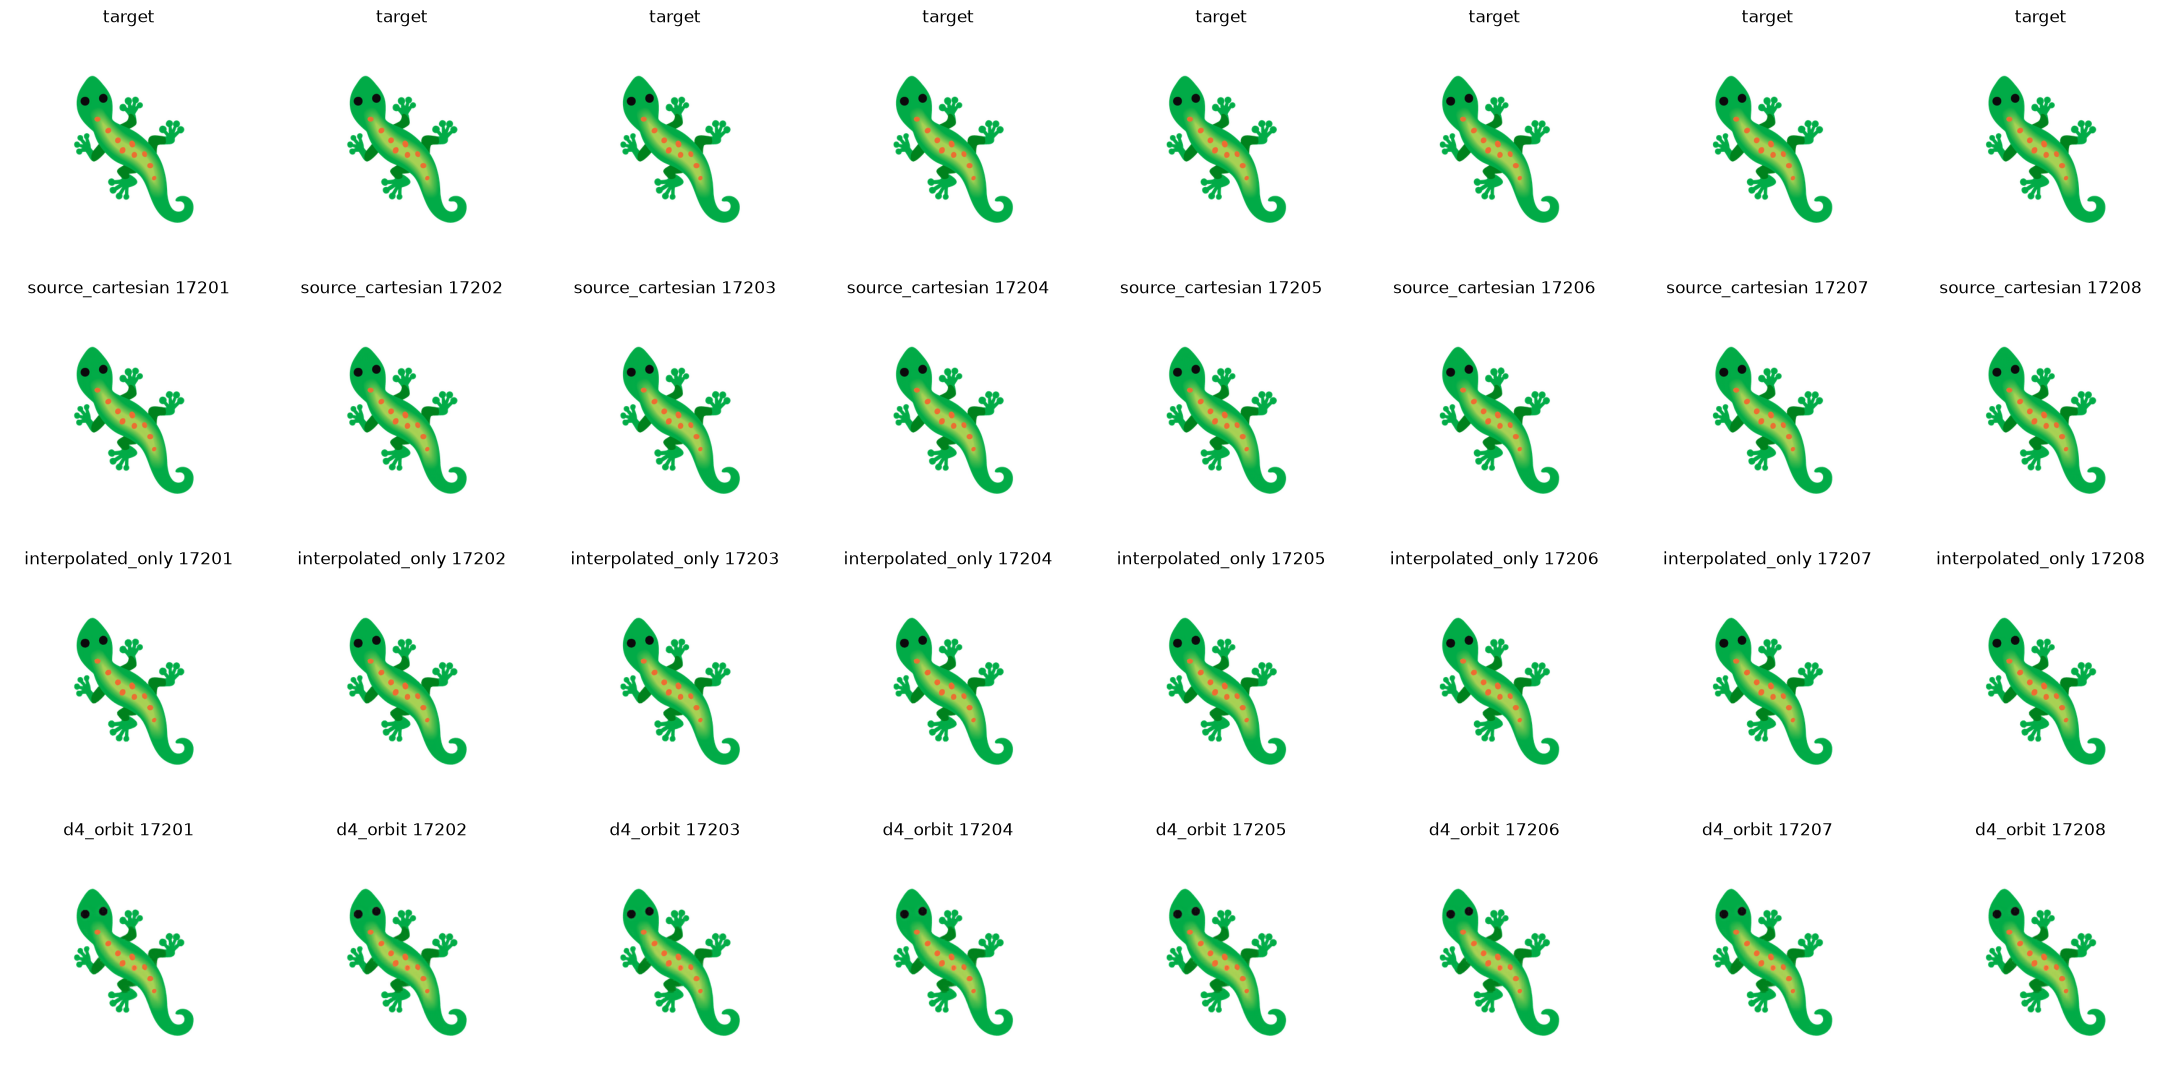

D4: {
  "source_cartesian": {
    "max_abs": 0.223876953125,
    "by_transform": [
      0.223876953125,
      0.13232421875,
      0.1982421875,
      0.147216796875,
      0.18310546875,
      0.134765625,
      0.21240234375
    ],
    "pass_1e_5": false
  },
  "interpolated_only": {
    "max_abs": 0.00048828125,
    "by_transform": [
      0.00048828125,
      0.00048828125,
      0.00048828125,
      0.00048828125,
      0.00048828125,
      0.0003662109375,
      0.0003662109375
    ],
    "pass_1e_5": false
  },
  "d4_orbit": {
    "max_abs": 4.76837158203125e-07,
    "by_transform": [
      3.5762786865234375e-07,
      4.76837158203125e-07,
      2.384185791015625e-07,
      3.5762786865234375e-07,
      3.5762786865234375e-07,
      3.5762786865234375e-07,
      3.5762786865234375e-07
    ],
    "pass_1e_5": true
  }
}
Decision: d4_orbit_needed_for_sharp_v14a_state
Download: /workspace/v17a_frozen_v14a_d4_readout_bridge_artifacts.tar.gz


In [8]:
#@title Post-lock audit, exact-D4 checks, decision, and export
audit_bank = make_bank(AUDIT_SEEDS)
decoders = {}
for arm in ARMS:
    decoder = make_decoder(arm).eval()
    decoder.load_state_dict(arm_results[arm]['decoder'])
    decoder.requires_grad_(False)
    decoders[arm] = decoder

def metrics_for(prediction, state_up, target):
    rgba_l1 = float((prediction - target).abs().mean())
    rgba_l2 = float((prediction - target).square().mean())
    shape_l1 = float((2 * state_up[:, 3:4] - target[:, 3:4]).abs().mean())
    shape_l2 = float((2 * state_up[:, 3:4] - target[:, 3:4]).square().mean())
    perceptual = float(lpips_loss(
        prediction[:, :3, 64:-64, 64:-64],
        target[:, :3, 64:-64, 64:-64], normalize=True).mean())
    return dict(l1=rgba_l1, l2=rgba_l2, shape_l1=shape_l1,
                shape_l2=shape_l2, lpips=perceptual,
                quality=rgba_l1 + rgba_l2 + shape_l1 + shape_l2 + perceptual)

@torch.no_grad()
def evaluate(name):
    rows, panels = [], []
    for item in audit_bank:
        state = item['state'].to(device)
        if name == 'source_cartesian':
            prediction, state_up, _ = render_source(state)
        else:
            prediction, state_up, _ = render_state(state, decoders[name], name)
        row = dict(seed=item['seed'], **metrics_for(
            prediction, state_up, canonical_target))
        rows.append(row)
        if len(panels) < 8:
            panels.append(prediction[0].detach().cpu())
    keys = ('l1', 'l2', 'shape_l1', 'shape_l2', 'lpips', 'quality')
    mean = {key: float(np.mean([row[key] for row in rows])) for key in keys}
    mean['worst_quality'] = max(row['quality'] for row in rows)
    return dict(rows=rows, mean=mean), panels

evaluations, panels = {}, {}
for name in ('source_cartesian',) + ARMS:
    evaluations[name], panels[name] = evaluate(name)
    print(name, json.dumps(evaluations[name]['mean'], indent=2))

@torch.no_grad()
def d4_error(name):
    set_all_seeds(BASE_SEED + 99)
    state = torch.randn(1, 32, 12, 12, device=device) * 0.1
    state[:, 3:4] = 1.0
    if name == 'source_cartesian':
        base = render_source(state)[0]
    else:
        base = render_state(state, decoders[name], name)[0]
    errors = []
    for transform in range(1, 8):
        transformed_state = d4_apply(state, transform)
        if name == 'source_cartesian':
            actual = render_source(transformed_state)[0]
        else:
            actual = render_state(transformed_state, decoders[name], name)[0]
        errors.append(float((actual - d4_apply(base, transform)).abs().max()))
    return dict(max_abs=max(errors), by_transform=errors,
                pass_1e_5=max(errors) < D4_LIMIT)

d4 = {name: d4_error(name) for name in ('source_cartesian',) + ARMS}
passes = {}
for arm in ARMS:
    summary = evaluations[arm]['mean']
    passes[arm] = bool(
        summary['quality'] <= SHARP_MEAN_LIMIT
        and summary['worst_quality'] <= SHARP_WORST_LIMIT
        and d4[arm]['pass_1e_5'])

source_valid = evaluations['source_cartesian']['mean']['quality'] <= SOURCE_MEAN_LIMIT
best_arm = min(ARMS, key=lambda arm: evaluations[arm]['mean']['quality'])
best_quality = evaluations[best_arm]['mean']['quality']
if not source_valid:
    decision = 'invalid_v14a_source_control_not_reproduced'
elif passes['interpolated_only']:
    decision = 'interpolated_only_transfers_sharp_v14a_state'
elif passes['d4_orbit']:
    decision = 'd4_orbit_needed_for_sharp_v14a_state'
elif best_quality <= 0.5 * V14C_AGE128_QUALITY and d4[best_arm]['pass_1e_5']:
    decision = 'd4_readout_partial_but_not_sharp'
else:
    decision = 'v14a_state_not_sharp_under_tested_d4_readouts'

fig, axes = plt.subplots(4, 8, figsize=(22, 11))
target = canonical_target[0].detach().cpu().clamp(0, 1)
for column in range(8):
    axes[0, column].imshow(
        (target[:3] + 1 - target[3:4]).permute(1, 2, 0).clamp(0, 1))
    axes[0, column].set_title('target')
    axes[0, column].axis('off')
for row_index, name in enumerate(('source_cartesian',) + ARMS, 1):
    for column, rgba in enumerate(panels[name]):
        rgba = rgba.clamp(0, 1)
        axes[row_index, column].imshow(
            (rgba[:3] + 1 - rgba[3:4]).permute(1, 2, 0).clamp(0, 1))
        axes[row_index, column].set_title(name + ' ' + str(AUDIT_SEEDS[column]))
        axes[row_index, column].axis('off')
fig.tight_layout()
panel_path = OUTPUT_ROOT / 'v14a_d4_readout_bridge.png'
fig.savefig(panel_path, dpi=150)
plt.show()
plt.close(fig)

metrics = dict(
    status='complete', config=config,
    source_reference_mean=reference_metrics['evaluation']['mean'],
    selected={arm: dict(step=arm_results[arm]['selected_step'],
                        objective=arm_results[arm]['selected_objective'])
              for arm in ARMS},
    evaluations=evaluations, d4=d4, sharp_pass=passes,
    source_valid=source_valid, best_arm=best_arm, decision=decision,
    interpretation=(
        'This decoder-only bridge uses scalar spatial transforms of frozen '
        'anisotropic V14a states. A pass validates readout capacity and D4 '
        'behavior, not isotropic growth dynamics.'))
(OUTPUT_ROOT / 'metrics.json').write_text(json.dumps(metrics, indent=2))
archive_path = WORKSPACE_ROOT / (SLUG + '_artifacts.tar.gz')
with tarfile.open(archive_path, 'w:gz') as archive:
    for name in ('config.json', 'metrics.json', 'interpolated_only_decoder.pth',
                 'd4_orbit_decoder.pth', 'interpolated_only_history.json',
                 'd4_orbit_history.json', 'v14a_d4_readout_bridge.png'):
        archive.add(OUTPUT_ROOT / name, arcname=SLUG + '/' + name)
print('D4:', json.dumps(d4, indent=2))
print('Decision:', decision)
print('Download:', archive_path)
